# Train Seq to Seq

In [ ]:
import torch
from torch import nn
import pandas as pd

In [268]:
df_train = pd.read_csv('field_f2')
df_train.drop('datetime', axis=1, inplace=True)
print(df_train.shape)
print(df_train.columns)
#df_train.set_index('datetime', inplace=True)

df_test = pd.read_csv('field_f10')
df_test.drop('datetime', axis=1, inplace=True)
print(df_test.shape)
print(df_test.columns)
#df_test.set_index('datetime', inplace=True)

(3698, 14)
Index(['s_a', 's_b', 'irr', 'temperature_2m', 'relative_humidity_2m',
       'cloud_cover', 'wind_speed_10m', 'wind_direction_100m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'rain', 'precipitation',
       'evapotranspiration'],
      dtype='object')
(3698, 14)
Index(['s_a', 's_b', 'irr', 'temperature_2m', 'relative_humidity_2m',
       'cloud_cover', 'wind_speed_10m', 'wind_direction_100m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'rain', 'precipitation',
       'evapotranspiration'],
      dtype='object')


In [269]:
df_test

,s_a,s_b,irr,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,wind_direction_100m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,rain,precipitation,evapotranspiration
0,13.345000,12.100000,0.0,18.1,35,0,6.4,311,14.3,12.0,17.0,0.0,0.0,0.31
1,13.363333,12.113333,0.0,18.9,34,0,7.1,334,15.1,12.2,17.0,0.0,0.0,0.32
2,13.376667,12.126667,0.0,18.9,33,1,7.0,351,16.0,12.5,17.0,0.0,0.0,0.29
3,13.426667,12.133333,0.0,17.8,41,1,9.6,40,16.2,12.8,17.0,0.0,0.0,0.23
4,13.463333,12.163333,0.0,15.9,50,0,8.4,74,15.7,13.1,17.0,0.0,0.0,0.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3693,17.113333,17.113333,0.0,20.1,53,0,18.8,245,18.7,17.9,18.7,0.0,0.0,0.35
3694,17.103333,17.106667,0.0,21.5,47,29,20.0,281,20.1,18.0,18.7,0.1,0.1,0.47
3695,17.100000,17.103333,0.0,21.6,47,19,18.9,297,21.1,18.2,18.7,0.1,0.1,0.47
3696,17.116667,17.096667,0.0,22.5,45,35,15.9,303,22.2,18.5,18.7,0.1,0.1,0.56


In [270]:
import torch
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_window, output_window, out_features_list, shift):
        """
        Args:
            data (torch.Tensor or np.array): time series data, shape (time_steps, features) or (time_steps,)
            input_window (int): number of time steps for input
            output_window (int): number of time steps to predict
        """
        if isinstance(data, np.ndarray):
            data = torch.tensor(data, dtype=torch.float32)

        self.data = data
        self.input_window = input_window
        self.output_window = output_window
        self.out_features_list = out_features_list
        self.shift = shift
        self.length = len(data) - input_window - output_window + 1 - self.shift

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_window]
        y = self.data[idx + self.input_window + self.shift : idx + self.input_window + self.output_window + self.shift, self.out_features_list]
        
        
        return x, y

In [271]:
import torch
import random
import numpy as np

# Define the seed value
seed = 42

# Set seed for PyTorch
torch.manual_seed(seed)

# Set seed for CUDA (if using GPUs)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

# Set seed for Python's random module
random.seed(seed)

# Set seed for NumPy
np.random.seed(seed)

# Ensure deterministic behavior for PyTorch operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [272]:
#model
input_size = 14
hidden_size = 20
output_size = 2

input_seq_len = 30 # dataset
output_seq_len = 12 # dataset
out_features_list = [0,1] # dataset
shift = 24 #dataset



In [273]:
import numpy as np
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

# Dummy time series data
#time_series = np.sin(np.linspace(0, 100, 500))  # shape: (500,)
time_series_train = df_train.to_numpy()
time_series_test = df_test.to_numpy()

scaler = StandardScaler()
scaler.fit(time_series_train)
time_series_train = scaler.transform(time_series_train.astype(float))
time_series_test = scaler.transform(time_series_test.astype(float))
#time_series_train = StandardScaler().fit(time_series_train).transform(time_series_train.astype(float))


dataset_train = TimeSeriesDataset(time_series_train, input_seq_len, output_seq_len, out_features_list, shift)
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

dataset_test = TimeSeriesDataset(time_series_test, input_seq_len, output_seq_len, out_features_list, shift)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=True)

# Fetch one batch
for x_batch, y_batch in dataloader_train:
    print("Input batch shape:", x_batch.shape)   # (batch_size, input_seq_len, features_in)
    print("Target batch shape:", y_batch.shape)  # (batch_size, output_seq_len, features_target)
    break

Input batch shape: torch.Size([32, 30, 14])
Target batch shape: torch.Size([32, 12, 2])


In [274]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)

    def forward(self, x):
        # x: (batch_size, input_seq_len, input_size)
        outputs, hidden = self.rnn(x)  # hidden: (1, batch, hidden_size)
        return hidden


class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size):
        super(Decoder, self).__init__()
        self.rnn = nn.RNN(input_size=output_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, decoder_input, hidden):
        # decoder_input: (batch_size, 1, output_size) ← one timestep
        output, hidden = self.rnn(decoder_input, hidden)
        output = self.fc(output)  # (batch_size, 1, output_size)
        return output, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, output_seq_len):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.output_seq_len = output_seq_len

    def forward(self, x):
        batch_size = x.size(0)
        output_size = self.decoder.fc.out_features
        
        hidden = self.encoder(x)

        # Start with zeros or a special <START> token
        decoder_input = torch.zeros(batch_size, 1, output_size, device=x.device)

        outputs = []

        for _ in range(self.output_seq_len):
            output, hidden = self.decoder(decoder_input, hidden)
            outputs.append(output)
            decoder_input = output  # Teacher forcing could go here

        return torch.cat(outputs, dim=1)

100%|██████████| 20/20 [00:10<00:00,  1.98it/s]

Best trein Loss: 0.18487948270743354
Best trein Loss: 0.16443999111652374


<function matplotlib.pyplot.show(close=None, block=None)>

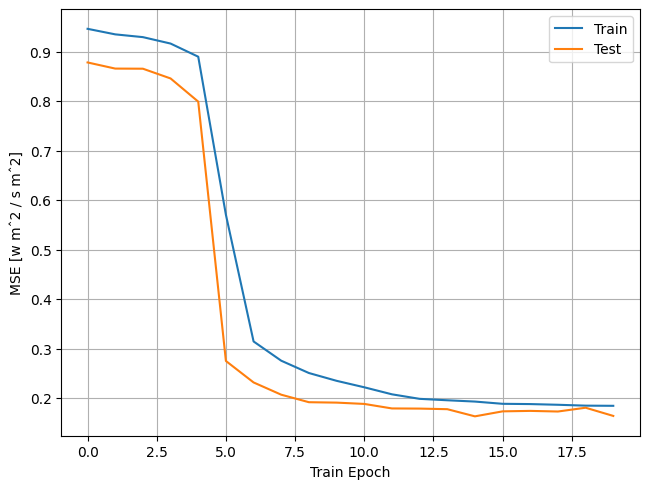

In [275]:
from tqdm import tqdm
from matplotlib import pyplot as plt


# Example
batch_size = 32
epochs = 20

encoder = Encoder(input_size, hidden_size)
decoder = Decoder(output_size, hidden_size)
model = Seq2Seq(encoder, decoder, output_seq_len)

#x = torch.randn(32, input_seq_len, input_size)
#y = model(x)
#print(y.shape)  

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.MSELoss()
train_losses = np.zeros(epochs)
test_losses = np.zeros(epochs)
mse_overEpoches = np.zeros(epochs)

for epoch in tqdm(range(epochs)):
    model.train()
    train_loss = 0.
    count = 0
    for x_batch, y_batch in dataloader_train:
        count += 1
        x_batch = x_batch.type(torch.float32)
        y_batch = y_batch.type(torch.float32)
        # Forward pass
        outputs = model(x_batch)

        loss = criterion(outputs, y_batch)
        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_losses[epoch] = train_loss / count

    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_loss = 0.
        mse_s = 0.
        count = 0
        for x_batch, y_batch in dataloader_test:
            count += 1
            x_batch = x_batch.type(torch.float32)
            y_batch = y_batch.type(torch.float32)
            # Forward pass
            outputs = model(x_batch)

            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
            mse = torch.mean((y_batch - outputs) ** 2)
            mse_s += mse

        mse_overEpoches[epoch] = mse_s / count
        test_losses[epoch] = test_loss / count

print(f"Best trein Loss: {train_losses[-1]}")
print(f"Best trein Loss: {mse_overEpoches[-1]}")
plt.plot(train_losses, label='Train',)
plt.plot(test_losses, label='Test',)
#plt.plot(mse_overEpoches, label='MSE',)
plt.legend()  # <--- this adds the legend
plt.grid(True)
plt.tight_layout()
plt.xlabel("Train Epoch")
plt.ylabel("MSE [w mˆ2 / s mˆ2]")
plt.savefig('test.png', dpi=300, bbox_inches='tight')
plt.show

In [277]:
plt.savefig('test.jpeg')

<Figure size 640x480 with 0 Axes>